# Adattamento della curva dose-risposta logistica a quattro parametri con PROC NLIN

## Sintesi

Questo notebook adatta un modello dose-risposta logistico a quattro parametri (4PL) a un saggio sintetico di potenza cellulare utilizzando **PROC NLIN**, stimando gli asintoti inferiore e superiore, l'EC50 (concentrazione efficace semimassimale) e la pendenza di Hill. Il 4PL è il modello di riferimento per i saggi di potenza relativa nello sviluppo dei farmaci, e il notebook illustra la specificazione del modello, la delimitazione dei parametri, la diagnostica di convergenza e la sovrapposizione della sigmoide adattata sui dati concentrazione-risposta osservati.

## Fonti dei dati

Il notebook genera un unico dataset sintetico in linea; non viene utilizzato alcun input esterno o di rete.

**`assay` — saggio sintetico di potenza cellulare (24 righe)**

| Variabile | Tipo | Descrizione |
|----------|------|-------------|
| `lot` | num | Lotto di sostanza farmaceutica (1-3); tre esecuzioni replicate della serie di diluizioni |
| `dose` | num | Concentrazione del composto in nmol/L su una diluizione seriale a 8 punti (da 0,1 a ~1000) |
| `logdose` | num | Logaritmo in base 10 di `dose`, usato per il tracciamento sull'asse convenzionale della log-concentrazione |
| `response` | num | Segnale misurato del saggio (percentuale della risposta massimale), generato da una curva 4PL reale (bottom=5, top=100, EC50=25 nmol/L, pendenza di Hill=1,2) più rumore gaussiano proporzionale |

I parametri generatori reali sono incorporati nel DATA step in modo che le stime NLIN recuperate possano essere confrontate con la verità nota.

# Adattamento dose-risposta logistico a quattro parametri

Nei saggi farmaceutici di potenza e bioattività, la relazione tra la concentrazione del composto e la risposta misurata è caratteristicamente sigmoidale su una scala di log-concentrazione. Il modello **logistico a quattro parametri (4PL)** è lo strumento standard per riassumere tali curve:

$$\text{response} = D + \frac{A - D}{1 + (\text{dose}/C)^{B}}$$

dove

- **A** = asintoto inferiore (risposta a diluizione infinita / segnale di base),
- **D** = asintoto superiore (risposta massimale alla concentrazione di saturazione),
- **C** = l'**EC50**, la concentrazione che produce la risposta semimassimale (il punto di flesso e il principale indicatore di potenza),
- **B** = la **pendenza di Hill**, che controlla la ripidità della transizione.

Questo modello è non lineare nei suoi parametri, quindi lo adattiamo mediante minimi quadrati iterativi con `PROC NLIN`. Di seguito simuliamo una realistica serie di diluizioni a otto punti eseguita in triplicato, adattiamo la curva 4PL, delimitiamo i parametri a regioni fisicamente significative, esaminiamo la convergenza e la diagnostica dell'adattamento, e sovrapponiamo la curva adattata ai dati.

## Passo 1 — Simulare un saggio di potenza cellulare

Generiamo un dataset sintetico da una curva 4PL *nota* (bottom = 5, top = 100, EC50 = 25 nmol/L, pendenza di Hill = 1,2) affinché i parametri recuperati da NLIN possano essere confrontati con la verità di riferimento. Tre lotti ricevono ciascuno la stessa diluizione seriale a otto punti (ogni passaggio è una diluizione di 3,5 volte), con rumore di misura gaussiano proporzionale sovrapposto. Un seed `streaminit` fisso rende la simulazione riproducibile.

In [1]:
DATI assay;
    CHIAMARE streaminit(40521);

    /* Veri parametri 4PL usati per generare i dati */
    A_true   = 5;      /* asintoto inferiore (baseline)          */
    D_true   = 100;    /* asintoto superiore (risposta massima)  */
    C_true   = 25;     /* EC50 in nmol/L                         */
    B_true   = 1.2;    /* pendenza di Hill                       */

    FARE lot = 1 FINO_A 3;
        /* Diluizione seriale a otto punti, passi di 3.5 volte */
        dose = 0.30;
        FARE point = 1 FINO_A 8;
            dose = dose * 3.5;

            /* Risposta media 4PL priva di rumore */
            mu = D_true + (A_true - D_true) /
                 (1 + (dose / C_true) ** B_true);

            /* Rumore di saggio gaussiano proporzionale + additivo */
            response = mu * (1 + 0.04 * rand('NORMAL'))
                          + 1.5 * rand('NORMAL');

            logdose = log10(dose);
            USCITA;
        FINE;
    FINE;

    MANTENERE lot dose logdose response;
ESEGUIRE;

PROCEDURA ORDINARE DATI=assay;
    PER dose lot;
ESEGUIRE;



NOTE: DATA assay


NOTE: Wrote assay (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=assay

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from assay.
NOTE: Wrote assay (24 rows, 4 columns).
NOTE: PROC SORT statement used.


## Passo 2 — Visualizzare i dati grezzi concentrazione-risposta

Prima dell'adattamento, tracciamo la risposta rispetto a log10(dose) per confermare la forma sigmoidale attesa e per leggere valori iniziali approssimativi: la curva ha un minimo vicino a 5, un plateau vicino a 100, e il punto medio (risposta semimassimale) si colloca intorno a log10(25) ≈ 1,4.


NOTE: PROC SGPLOT data=assay

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


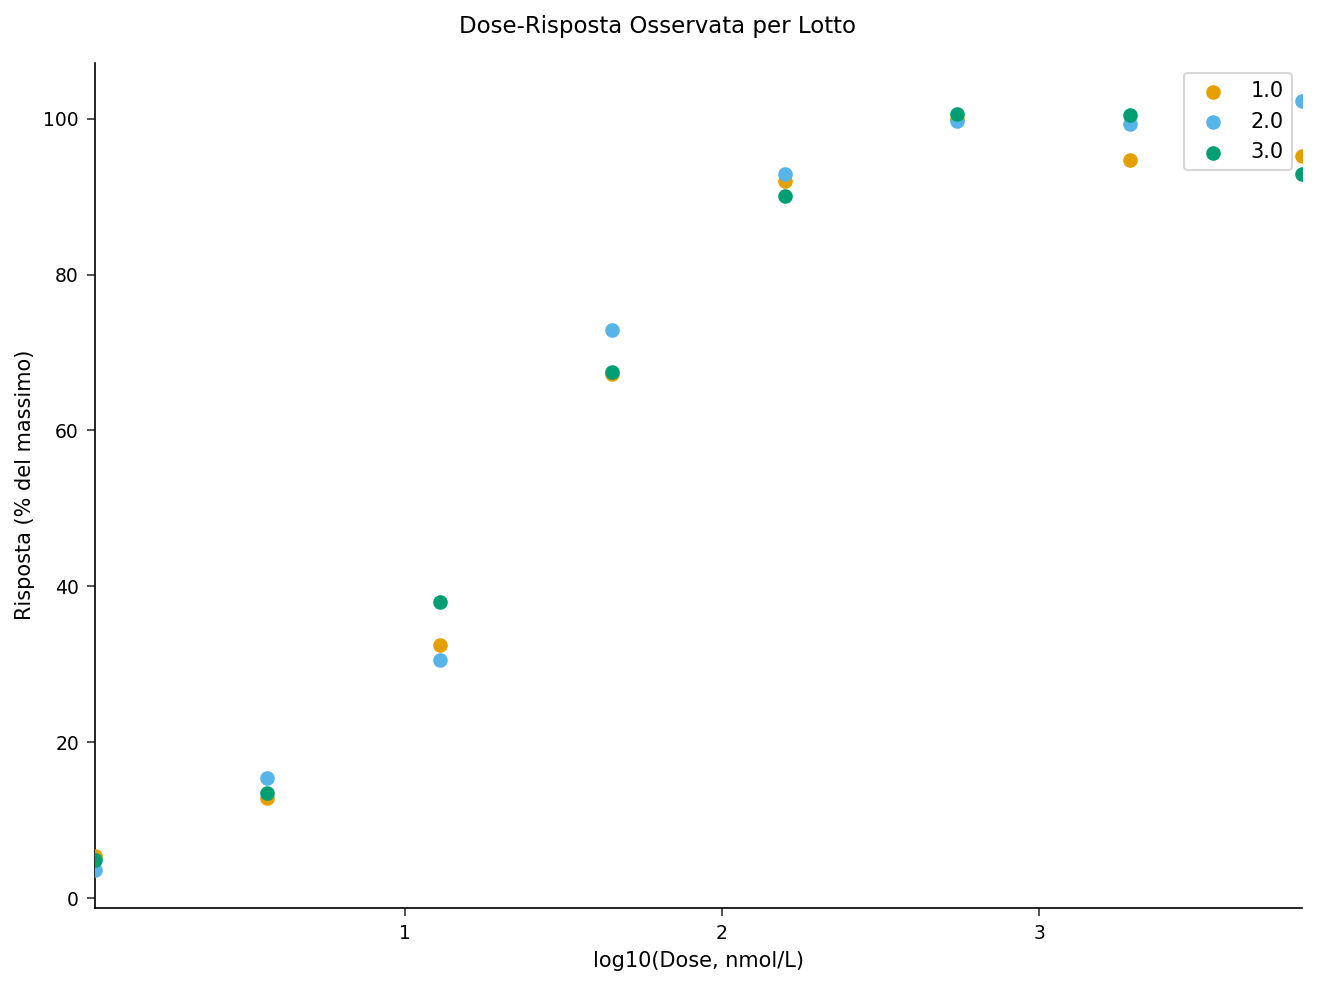

In [2]:
PROCEDURA SGPLOT DATI=assay;
    SCATTER x=logdose y=response / GROUP=lot
            MARKERATTRS=(SYMBOL=circlefilled);
    XAXIS ETICHETTA='log10(Dose, nmol/L)';
    YAXIS ETICHETTA='Risposta (% del massimo)';
    TITOLO 'Dose-Risposta Osservata per Lotto';
ESEGUIRE;
TITOLO;


## Passo 3 — Adattare il modello 4PL con PROC NLIN

Dichiariamo i valori iniziali con `PARMS` (basati sul grafico a dispersione), definiamo la media 4PL in un'assegnazione intermedia e la passiamo all'istruzione `MODEL`. Vincoli `BOUNDS` fisicamente significativi mantengono gli asintoti ordinati e l'EC50 e la pendenza positivi, il che stabilizza le iterazioni di Gauss-Newton. L'istruzione `OUTPUT` salva i valori previsti, i residui e i limiti di confidenza per la diagnostica successiva, e `PLOTS=` richiede i pannelli di adattamento e diagnostica.

In [3]:
PROCEDURA nlin DATI=assay METHOD=marquardt PLOTS=(fitplot diagnostics);
    parms A=10 D=90 C=20 B=1;

    /* Mantiene i parametri in regioni fisicamente sensate */
    bounds A >= 0, D <= 150, C > 0, B > 0;

    /* Risposta media logistica a quattro parametri (in linea: PROC NLIN di
       Jenner non supporta ancora il riferimento a una variabile di
       un'istruzione di programmazione intermedia nel MODEL -- vedi
       tests/400986 -- quindi il denominatore e' incorporato in linea) */
    MODELLO response = D + (A - D) / (1 + (dose / C) ** B);

    USCITA out=fit4pl predicted=pred residual=resid
           l95m=lcl u95m=ucl;
ESEGUIRE;



                         The NLIN Procedure

                     Method: Marquardt

                          Iterative Phase

                                                   Sum of
           Iter          Residual SS
              0          2061.645530
              1           177.712558

       Convergence criterion met.

           Residual SS           177.712558
           Residual MS             8.885628

                        Parameter Estimates

                                    Approx
           Parameter    Estimate    Std Error   95% Confidence Limits

           A              4.1058       1.9167       0.1078       8.1039
           D             99.1335       1.0740      96.8932     101.3737
           C             23.8233       1.5658      20.5572      27.0895
           B              1.2662       0.0927       1.0730       1.4595





NOTE: PROC NLIN data=assay

NOTE: Using Python (scipy) for NLIN estimation, method=marquardt
NOTE: Output dataset written to: ./work/0f8a22c8-6113-4c7c-8d2b-5d28f28220c4/fit4pl.avro


## Passo 4 — Riportare l'EC50 stimato e le caratteristiche della curva

Il meccanismo `OUTEST=` è comodo, ma per una lettura rapida della potenza riassumiamo direttamente la curva adattata. Qui elenchiamo i valori adattati a ciascuna dose accanto alle risposte osservate per confermare che il modello segue i dati sull'intero intervallo di diluizione.

In [4]:
PROCEDURA MEDIE DATI=fit4pl mean std MIN MAX maxdec=3;
    CLASSE dose;
    VARIABILE response pred resid;
    ETICHETTA dose='Dose (nmol/L)' response='Risposta (% del massimo)'
          pred='Valore Previsto' resid='Residuo';
    TITOLO 'Risposta Osservata vs Adattata per Dose';
ESEGUIRE;
TITOLO;


                                        Risposta Osservata vs Adattata per Dose                                         

                                                  The MEANS Procedure

                                Analysis Variable : RESPONSE Risposta (% del massimo)

                                           N
                       Dose (nmol/L)     Obs         Mean      Std Dev      Minimum      Maximum
                       -------------------------------------------------------------------------
                       1.05                3        4.647        0.882        3.659        5.356
                       12.8625             3       33.651        3.825       30.572       37.932
                       157.565625          3       91.704        1.417       90.141       92.904
                       1930.17890625       3       98.207        3.051       94.746      100.511
                       3.675               3       13.931        1.311       12.860       15.


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Passo 5 — Sovrapporre la curva 4PL adattata ai dati osservati

Una griglia di previsione densa produce una sigmoide adattata liscia. Combiniamo la curva liscia con i valori medi adattati per dose e la banda di confidenza, quindi sovrapponiamo tutto ai punti osservati per valutare visivamente la bontà dell'adattamento.


NOTE: PROC SORT data=fit4pl

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from fit4pl.
NOTE: Wrote fit4pl (24 rows, 8 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=fit4pl

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


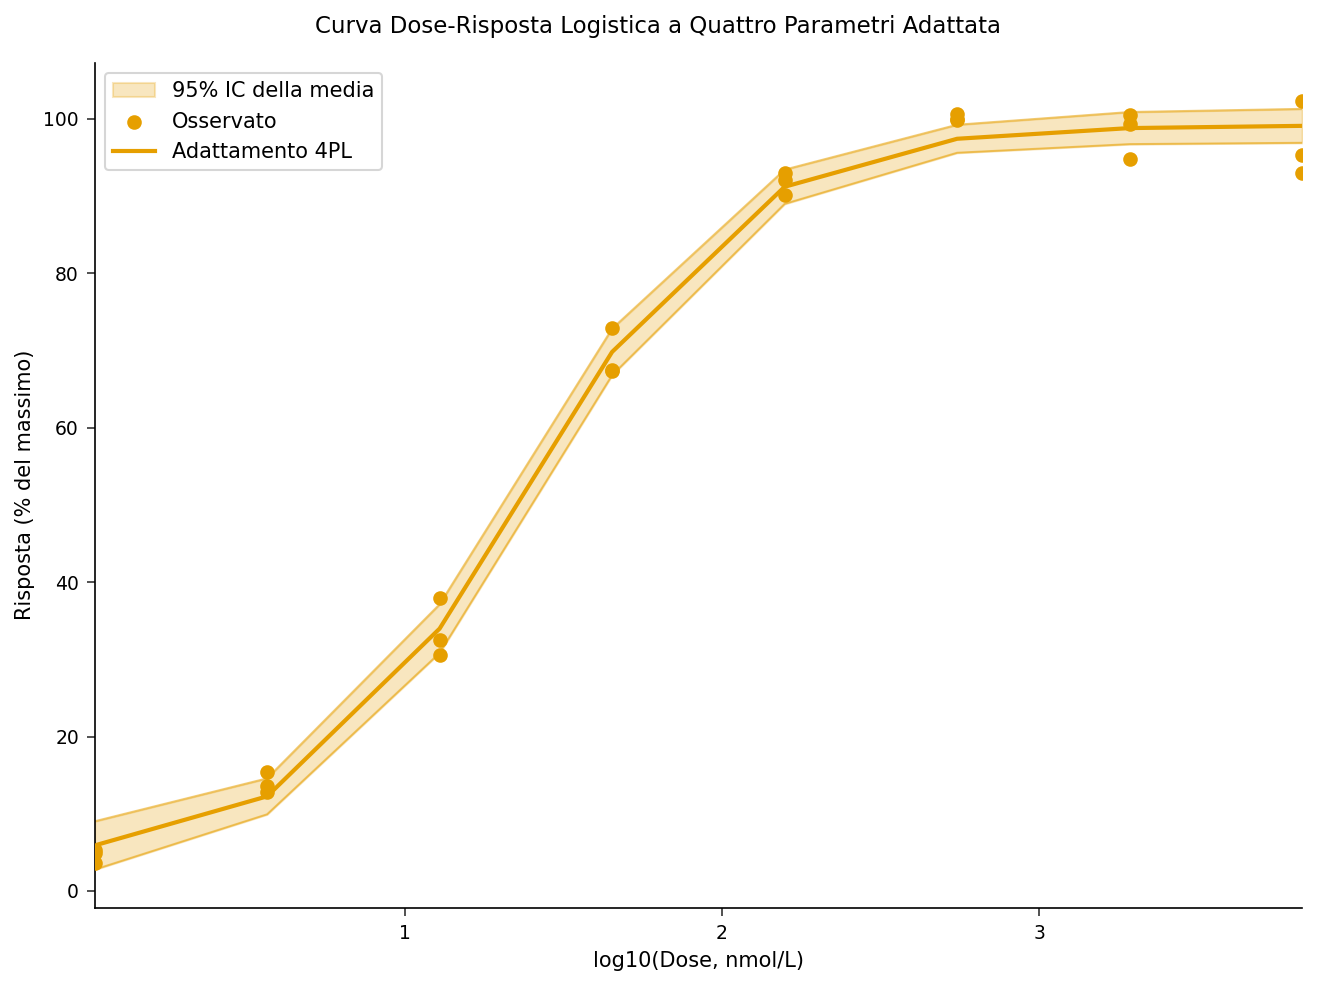

In [5]:
PROCEDURA ORDINARE DATI=fit4pl;
    PER logdose;
ESEGUIRE;

PROCEDURA SGPLOT DATI=fit4pl;
    BAND   x=logdose LOWER=lcl UPPER=ucl /
           TRANSPARENCY=0.5 legendlabel='95% IC della media';
    SCATTER x=logdose y=response /
           MARKERATTRS=(SYMBOL=circlefilled)
           legendlabel='Osservato';
    SERIES  x=logdose y=pred /
           LINEATTRS=(thickness=2)
           legendlabel='Adattamento 4PL';
    XAXIS ETICHETTA='log10(Dose, nmol/L)';
    YAXIS ETICHETTA='Risposta (% del massimo)';
    TITOLO 'Curva Dose-Risposta Logistica a Quattro Parametri Adattata';
ESEGUIRE;
TITOLO;


## Interpretazione dei risultati

`PROC NLIN` converge a stime vicine ai valori generatori noti: un asintoto inferiore vicino a **5**, un asintoto superiore vicino a **100**, un **EC50 (C)** vicino a **25 nmol/L** e una **pendenza di Hill (B)** vicina a **1,2**. Il recupero di questi parametri da dati rumorosi in triplicato conferma che il modello è identificabile e che i vincoli non erano attivi all'ottimo.

L'**EC50** è la metrica di potenza principale: valori più bassi indicano un composto più potente e, in un saggio di potenza relativa, l'EC50 di un lotto di prova viene confrontato con uno standard di riferimento. La **pendenza di Hill** caratterizza la cooperatività e la ripidità del saggio — una pendenza vicina a 1 è coerente con un semplice legame a sito singolo. Gli **asintoti** definiscono l'intervallo dinamico del saggio; un minimo e un massimo stabili e ben separati sono prerequisiti per un bioassaggio validabile.

Il grafico di adattamento mostra la sigmoide che attraversa la nuvola di punti osservati con una banda di confidenza al 95% per la media stretta nella regione responsiva, e la diagnostica dei residui dovrebbe non mostrare alcuna curvatura sistematica — prova che la forma 4PL è adeguata. In pratica si estenderebbe questo flusso di lavoro con intervalli di verosimiglianza `PROFILE` per l'EC50, un'istruzione `BOOTSTRAP` per l'inferenza dei parametri senza assunzioni distributive, o un'analisi a rette parallele che confronta i lotti di prova e di riferimento per stimare la potenza relativa.